# **CSCE 5218 / CSCE 4930 Deep Learning**

# **The Perceptron** (20 pt)


In [4]:
# Get the datasets
!curl --output test.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/test_small.txt
!curl --output train.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/train.txt


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   136  100   136    0     0    177      0 --:--:-- --:--:-- --:--:--   178
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 11645  100 11645    0     0  49799      0 --:--:-- --:--:-- --:--:-- 49978


In [6]:
# Take a peek at the datasets
!type train.dat
!type test.dat

A1	A2	A3	A4	A5	A6	A7	A8	A9	A10	A11	A12	A13	
1	1	0	0	0	0	0	0	1	1	0	0	1	0
0	0	1	1	0	1	1	0	0	0	0	0	1	0
0	1	0	1	1	0	1	0	1	1	1	0	1	1
0	0	1	0	0	1	0	1	0	1	1	1	1	0
0	1	0	0	0	0	0	1	1	1	1	1	1	0
0	1	1	1	0	0	0	1	0	1	1	0	1	1
0	1	1	0	0	0	1	0	0	0	0	0	1	0
0	0	0	1	1	0	1	1	1	0	0	0	1	0
0	0	0	0	0	0	1	0	1	0	1	0	1	0
1	0	1	1	1	0	0	0	1	1	1	0	1	1
0	1	1	0	1	0	1	1	1	1	1	1	1	1
0	0	1	1	0	0	1	0	0	1	1	1	1	0
1	0	1	1	0	0	1	1	0	1	0	0	1	1
0	0	1	1	0	0	0	0	1	0	1	1	1	0
1	0	0	0	0	0	1	0	1	1	0	1	1	0
0	1	1	1	1	1	0	0	1	0	1	0	1	1
1	0	0	0	1	0	1	1	1	1	1	1	1	0
1	0	0	0	0	1	1	0	1	1	1	1	1	0
1	0	0	1	0	1	0	1	1	0	0	1	1	0
0	0	1	1	0	1	1	0	0	0	0	1	1	0
1	1	1	0	0	1	1	1	1	1	0	1	1	1
0	1	1	1	1	1	0	0	0	1	0	1	1	0
0	0	1	1	0	1	0	1	0	1	1	1	1	0
1	0	0	1	0	1	1	1	1	0	0	1	1	0
0	0	1	0	0	0	1	0	0	0	0	0	1	0
1	0	1	0	0	0	1	1	0	0	0	1	1	0
1	0	0	0	0	1	0	0	0	1	0	1	1	0
1	0	0	0	1	1	1	0	0	1	0	1	1	0
1	0	0	0	0	0	1	1	1	1	1	0	1	0
0	0	1	1	0	1	0	1	0	0	1	0	1	0
0	1	1	0	0	0	1	1	1	1	0	1	1	0
0	0	0	0	1	1	1	1	0	0	0	0	1	0
0	1	1	0	1	1	1	1	0	0	0	1	1	0
0	1	0	1	0	0	0	1	0	0	0	1	1	0
1	0	

### Build the Perceptron Model

You will need to complete some of the function definitions below.  DO NOT import any other libraries to complete this. 

In [ ]:
import math
import itertools
import re


# Corpus reader, all columns but the last one are coordinates;
#   the last column is the label
def read_data(file_name):
    f = open(file_name, 'r')

    data = []
    # Discard header line
    f.readline()
    for instance in f.readlines():
        if not re.search('\t', instance): continue
        instance = list(map(int, instance.strip().split('\t')))
        # Add a dummy input so that w0 becomes the bias
        instance = [-1] + instance
        data += [instance]
    return data


def dot_product(array1, array2):
    #TODO: Return dot product of array 1 and array 2

    return sum([a*b for a,b in zip(array1, array2)]) 


def sigmoid(x):
    #TODO: Return outpout of sigmoid function on x
    return 1 / (1 + math.exp(-x))

# The output of the model, which for the perceptron is 
# the sigmoid function applied to the dot product of 
# the instance and the weights
def output(weight, instance):
    #TODO: return the output of the model 
    return sigmoid(dot_product(weight, instance))

# Predict the label of an instance; this is the definition of the perceptron
# you should output 1 if the output is >= 0.5 else output 0
def predict(weights, instance):
    #TODO: return the prediction of the model
    return 1 if output(weights, instance) >= 0.5 else 0


# Accuracy = percent of correct predictions
def get_accuracy(weights, instances):
    # You do not to write code like this, but get used to it
    correct = sum([1 if predict(weights, instance) == instance[-1] else 0
                   for instance in instances])
    return correct * 100 / len(instances)


# Train a perceptron with instances and hyperparameters:
#       lr (learning rate) 
#       epochs
# The implementation comes from the definition of the perceptron
#
# Training consists on fitting the parameters which are the weights
# that's the only thing training is responsible to fit
# (recall that w0 is the bias, and w1..wn are the weights for each coordinate)
#
# Hyperparameters (lr and epochs) are given to the training algorithm
# We are updating weights in the opposite direction of the gradient of the error,
# so with a "decent" lr we are guaranteed to reduce the error after each iteration.
def train_perceptron(instances, lr, epochs):

    #TODO: Initializing the weights including the bias W0 to 0.
    weights = [0] * (len(instances[0])-1)

    for _ in range(epochs):
        for instance in instances:
            #TODO: Forwards pass(calculate prediction), activation(sigmoid) and error calculation.
            in_value = dot_product(weights, instance)  
            output = sigmoid(in_value)
            error = instance[-1] - output
            #TODO: Backpropogation, update the weights according to the error and the learning rate.
            for i in range(0, len(weights)):
                weights[i] += lr * error * output * (1-output) * instance[i]

    return weights

## Run it

In [8]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
lr = 0.005
epochs = 5
weights = train_perceptron(instances_tr, lr, epochs)
accuracy = get_accuracy(weights, instances_te)
print(f"#tr: {len(instances_tr):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
      f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4


## Questions

Answer the following questions. Include your implementation and the output for each question.



### Question 1

In `train_perceptron(instances, lr, epochs)`, we have the follosing code:
```
in_value = dot_product(weights, instance)
output = sigmoid(in_value)
error = instance[-1] - output
```

Why don't we have the following code snippet instead?
```
output = predict(weights, instance)
error = instance[-1] - output
```

#### TODO Add your answer here (text only)

We use the continuous sigmoid output because it is differentiable, which is a requirement for Gradient Descent. If we used predict(), we would be using a step function (returning only 0 or 1). The derivative of a step function is zero everywhere (except at the threshold where it is undefined). This would make it impossible to calculate a meaningful gradient to update the weights. By using the sigmoid output, we can calculate how much a specific weight contributed to the error, allowing for "finer" adjustments during training.


### Question 2
Train the perceptron with the following hyperparameters and calculate the accuracy with the test dataset.

```
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]              # number of epochs
lr = [0.005, 0.01, 0.05]              # learning rate
```

TODO: Write your code below and include the output at the end of each training loop (NOT AFTER EACH EPOCH)
of your code.The output should look like the following:
```
# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
[and so on for all the combinations]
```
You will get different results with different hyperparameters.

#### TODO Add your answer here (code and output in the format above) 


In [17]:
tr_percent = [5, 10, 25, 50, 75, 100]
num_epochs = [5, 10, 20, 50, 100]
lr_array = [0.005, 0.01, 0.05, 0.1, 0.5]

for lr in lr_array:
    for tr_size in tr_percent:
        size = round(len(instances_tr) * tr_size / 100)
        pre_instances = instances_tr[0:size]
        for epochs in num_epochs:
            weights = train_perceptron(pre_instances, lr, epochs)
            accuracy = get_accuracy(weights, instances_te)
            print(f"# tr: {len(pre_instances):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
                  f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  20, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
# tr:  40, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  40, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  40, epochs:  20, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  40, epochs:  50, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr:  40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr: 100, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr: 100, epochs:  10, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
# tr: 100, epoch

In [18]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]     # number of epochs
lr_array = [0.005, 0.01, 0.05]        # learning rate

for lr in lr_array:
  for tr_size in tr_percent:
    for epochs in num_epochs:
      size =  round(len(instances_tr)*tr_size/100)
      pre_instances = instances_tr[0:size]
      weights = train_perceptron(pre_instances, lr, epochs)
      accuracy = get_accuracy(weights, instances_te)
    print(f"#tr: {len(pre_instances):0}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
            f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 42.9
#tr: 40, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 100, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 28.6
#tr: 200, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs: 100, learning r

### Question 3
Write a couple paragraphs interpreting the results with all the combinations of hyperparameters. Drawing a plot will probably help you make a point. In particular, answer the following:
- A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?
- B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?
   ```
#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 100 instances): 71.0
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
```
- C. Can you get higher accuracy with additional hyperparameters (higher than `80.0`)?
- D. Is it always worth training for more epochs (while keeping all other hyperparameters fixed)?

#### TODO: Add your answer here (code and text)

In general, more training data tends to help, but the final test accuracy depends on the interaction between: training size, learning rate, epochs.

A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?
Not necessarily. In many datasets, a model reaches a "saturation point" where additional data provides redundant information. If the 75% subset captures the underlying distribution of the data well, the accuracy may plateau, and adding the final 25% might only marginally improve results or even introduce noise.

B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?
In the second run, while the data amount increased, the learning rate was significantly lower. A lower learning rate with the same number of epochs often means the model hasn't traveled far enough along the gradient to reach the optimal weights. Essentially, the first run was more aggressive in learning, whereas the second run was too cautious and likely got stuck in a local minimum or simply didn't converge in time.

C. Can you get higher than 80.0 accuracy? 
With a simple single-layer Perceptron, it is difficult to exceed 80% if the data is not linearly separable. To achieve higher accuracy, we need to introduce a hidden layer transforming it into a Multi-Layer Perceptron or perform feature engineering to create non-linear combinations of the inputs.

D. Is it always worth training for more epochs? 
No. Training for too many epochs leads to overfitting. This occurs when the model starts memorizing the specific noise and outliers of the training set rather than the general pattern. When this happens, training accuracy continues to rise, but test accuracy begins to decline.

In [14]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 10.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.0 MB/s  0:00:00
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.0 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
   ---------------

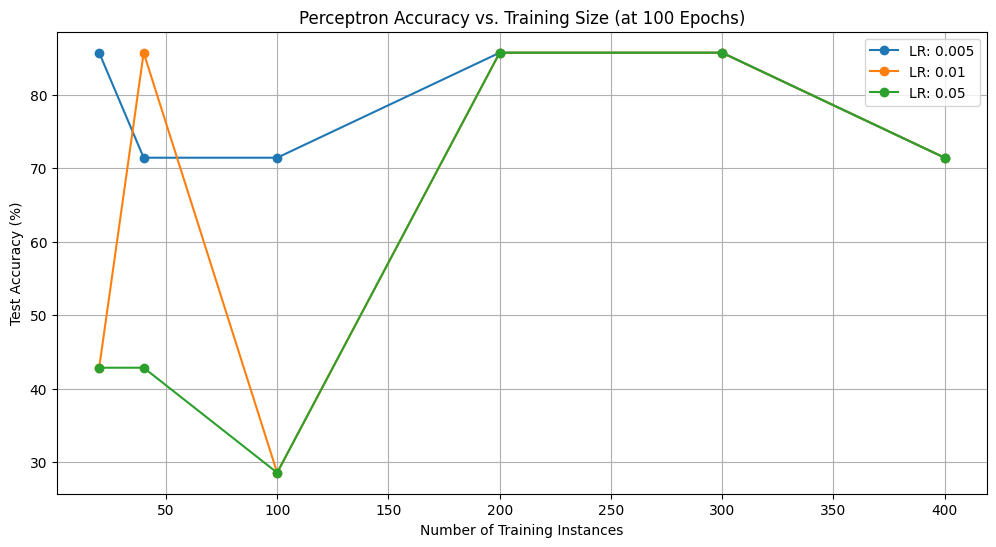

In [ ]:
import matplotlib.pyplot as plt

results = []
for lr in lr_array:
    for tr_size in tr_percent:
        size = round(len(instances_tr) * tr_size / 100)
        pre_instances = instances_tr[0:size]
        for epochs in num_epochs:
            weights = train_perceptron(pre_instances, lr, epochs)
            accuracy = get_accuracy(weights, instances_te)
            results.append({
                'lr': lr,
                'tr_size': len(pre_instances),
                'epochs': epochs,
                'accuracy': accuracy
            })

# 2. Plotting the results to interpret the trends
plt.figure(figsize=(12, 6))

for lr in lr_array:
    subset = [r for r in results if r['lr'] == lr and r['epochs'] == 100]
    x = [r['tr_size'] for r in subset]
    y = [r['accuracy'] for r in subset]
    plt.plot(x, y, marker='o', label=f'LR: {lr}')

plt.title('Perceptron Accuracy vs. Training Size (at 100 Epochs)')
plt.xlabel('Number of Training Instances')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()